**PROBLEMAS DE CLASIFICACIÓN**
* Stevens Bohorquez Ruiz

    +   *REGRESION LOGISTICA*
    -   Dataset: [Car Evaluation] (http://archive.ics.uci.edu/ml/datasets/Car+Evaluation)
    -   Tipo de característica: Categórico / # Instancias: 1728 / # Características: 6

**Objetivo:** El objetivo de este proyecto es analizar los datos de un data set para un problema de clasificación (regresión logística multiclase)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

car_evaluation = fetch_ucirepo(id=19)

X = car_evaluation.data.features
y = car_evaluation.data.targets

df = pd.DataFrame(X, columns=car_evaluation.metadata.features)
df['Target'] = y

df.to_csv('car_evaluation.csv', index=False)

print("Datos exportados a 'car_evaluation.csv'")

Datos exportados a 'car_evaluation.csv'


In [3]:
data = pd.read_csv('car_evaluation.csv')
print(data)

     buying  maint  doors persons lug_boot safety Target
0     vhigh  vhigh      2       2    small    low  unacc
1     vhigh  vhigh      2       2    small    med  unacc
2     vhigh  vhigh      2       2    small   high  unacc
3     vhigh  vhigh      2       2      med    low  unacc
4     vhigh  vhigh      2       2      med    med  unacc
...     ...    ...    ...     ...      ...    ...    ...
1723    low    low  5more    more      med    med   good
1724    low    low  5more    more      med   high  vgood
1725    low    low  5more    more      big    low  unacc
1726    low    low  5more    more      big    med   good
1727    low    low  5more    more      big   high  vgood

[1728 rows x 7 columns]


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   Target    1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [5]:
data.describe()

,buying,maint,doors,persons,lug_boot,safety,Target
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [6]:
print("Primeras filas del dataset:")
print(data.head())

Primeras filas del dataset:
  buying  maint doors persons lug_boot safety Target
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [7]:
columnas = data.columns.tolist()
# LabelEncoder para cada columna categorica
label_encoders = {}
for col in columnas[:-1]:  # menos target
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  

# target (objetivo)
target_encoder = LabelEncoder()
data['Target'] = target_encoder.fit_transform(data['Target'])


In [8]:
print(data)

      buying  maint  doors  persons  lug_boot  safety  Target
0          3      3      0        0         2       1       2
1          3      3      0        0         2       2       2
2          3      3      0        0         2       0       2
3          3      3      0        0         1       1       2
4          3      3      0        0         1       2       2
...      ...    ...    ...      ...       ...     ...     ...
1723       1      1      3        2         1       2       1
1724       1      1      3        2         1       0       3
1725       1      1      3        2         0       1       2
1726       1      1      3        2         0       2       1
1727       1      1      3        2         0       0       3

[1728 rows x 7 columns]


# Histograma (Variable Objetivo)

array([[<Axes: title={'center': 'buying'}>,
        <Axes: title={'center': 'maint'}>,
        <Axes: title={'center': 'doors'}>],
       [<Axes: title={'center': 'persons'}>,
        <Axes: title={'center': 'lug_boot'}>,
        <Axes: title={'center': 'safety'}>],
       [<Axes: title={'center': 'Target'}>, <Axes: >, <Axes: >]],
      dtype=object)

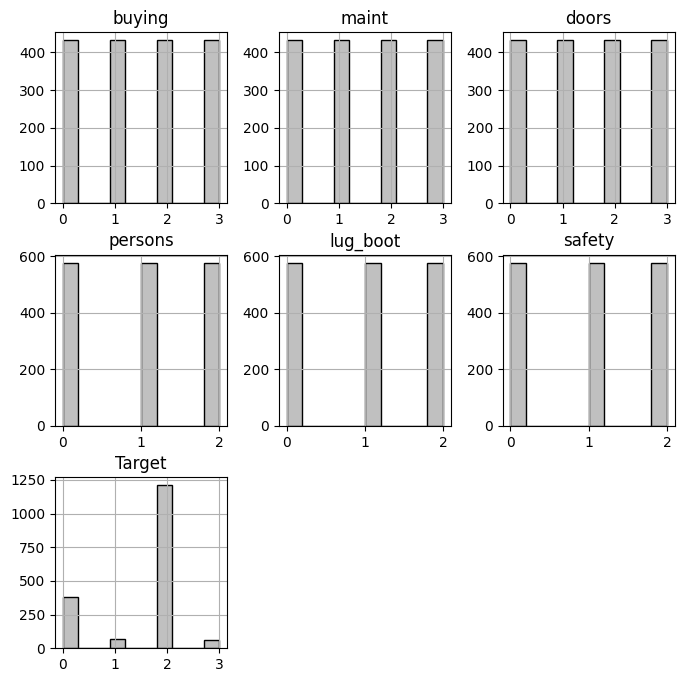

In [9]:
data.hist(figsize=(8, 8), bins=10, edgecolor='black', color='silver')

<Axes: >

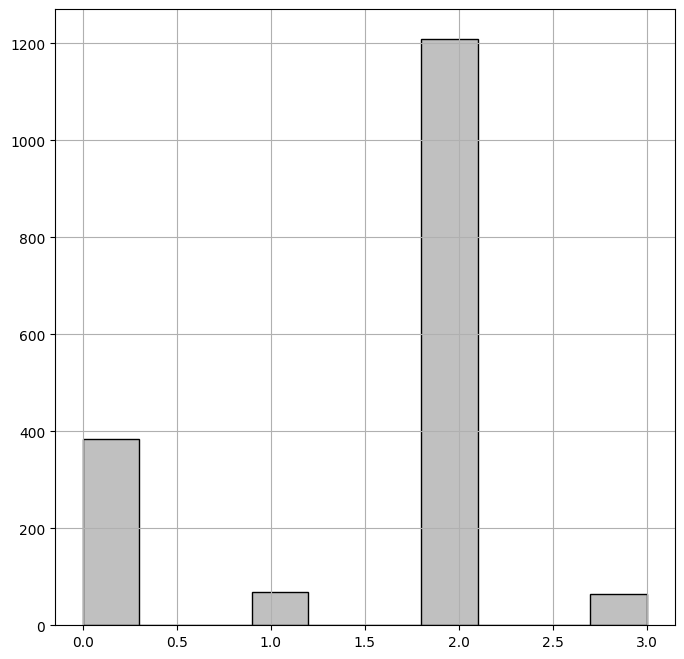

In [10]:
data['Target'].hist(figsize=(8, 8), bins=10, edgecolor='black', color='silver')

In [11]:
# Separo caracteristicas y etiqueta
X = data.iloc[:, :-1].values  # Todas menos la última columna ('Target')
Y = data['Target'].values  # Variable objetivo

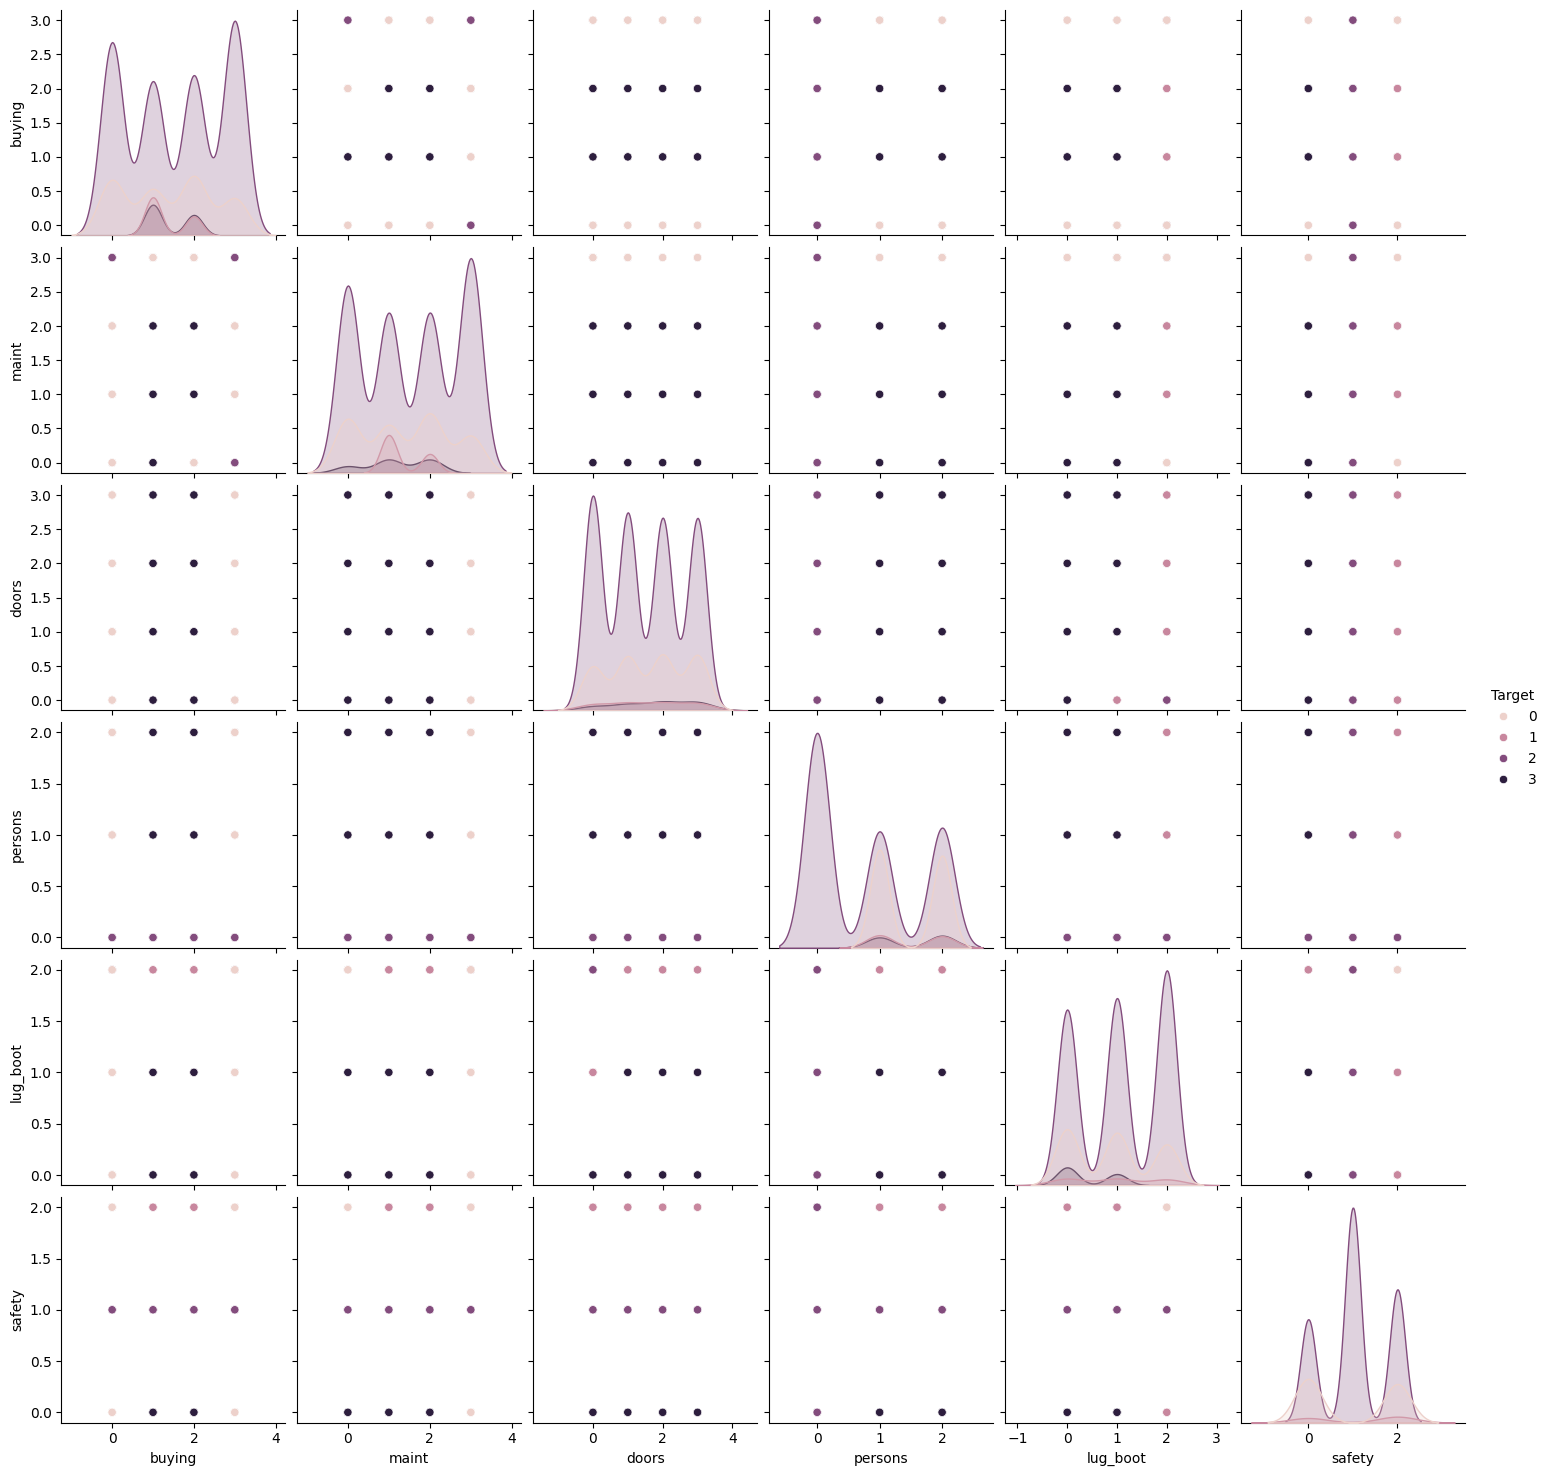

In [12]:
#grafico de dispersion para relaciones entre caracteristicas
sns.pairplot(data, hue="Target")
plt.show()

**Matriz de correlacion con la variable de datos normalizados para detectar variables significativas**

                buying         maint         doors       persons  \
buying    1.000000e+00 -3.436808e-16 -2.097088e-16 -4.089152e-17   
maint    -3.436808e-16  1.000000e+00 -6.466021e-17 -4.272143e-17   
doors    -2.097088e-16 -6.466021e-17  1.000000e+00  1.956599e-17   
persons  -4.089152e-17 -4.272143e-17  1.956599e-17  1.000000e+00   
lug_boot -1.691262e-16 -1.549092e-16 -1.942523e-17  3.854941e-18   
safety   -2.439415e-16 -1.404810e-16  1.062757e-16  3.392348e-17   
Target    5.142422e-02  4.019365e-02 -3.132740e-02 -2.994683e-01   

              lug_boot        safety    Target  
buying   -1.691262e-16 -2.439415e-16  0.051424  
maint    -1.549092e-16 -1.404810e-16  0.040194  
doors    -1.942523e-17  1.062757e-16 -0.031327  
persons   3.854941e-18  3.392348e-17 -0.299468  
lug_boot  1.000000e+00 -1.541976e-17  0.033184  
safety   -1.541976e-17  1.000000e+00 -0.021044  
Target    3.318432e-02 -2.104372e-02  1.000000  

Matriz de correlación convertida a int64:

          buying  m

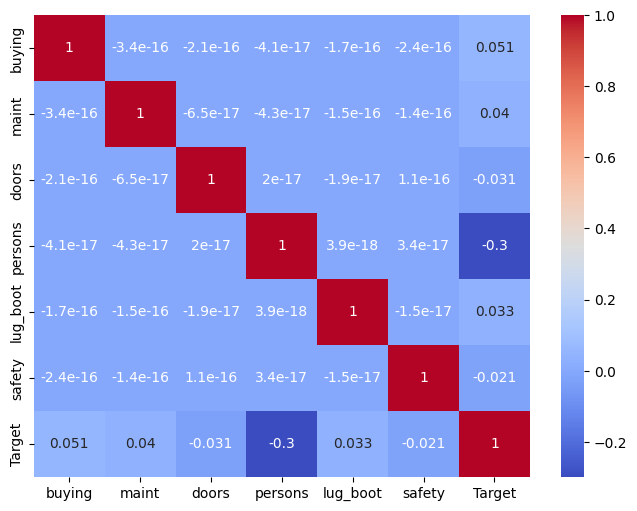

In [13]:
correlation_matrix = data.corr()
print(correlation_matrix)
print("")

#Convertimos a enteros
matriz_corr_int = correlation_matrix.round(0).astype('int64')
print("Matriz de correlación convertida a int64:")
print("")
print(matriz_corr_int)
print("")

plt.figure(figsize=(8, 6))
mapcorr = data.corr()

#Organizamos en orden ascendente 
#para saber los valores mas cercanos al target
correlation_with_target = mapcorr["Target"].sort_values(ascending=False)
print("")
print(correlation_with_target)
print("")

#Imprimimos mapa de calor con relacion a la matriz de correlacion.
sns.heatmap(mapcorr, cmap="coolwarm", annot=True)
plt.show()


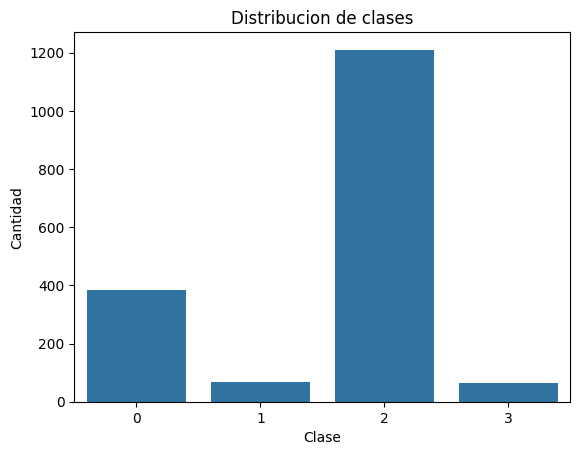

In [14]:
#Grafico de barras
sns.countplot(data=data, x='Target')
plt.title('Distribucion de clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

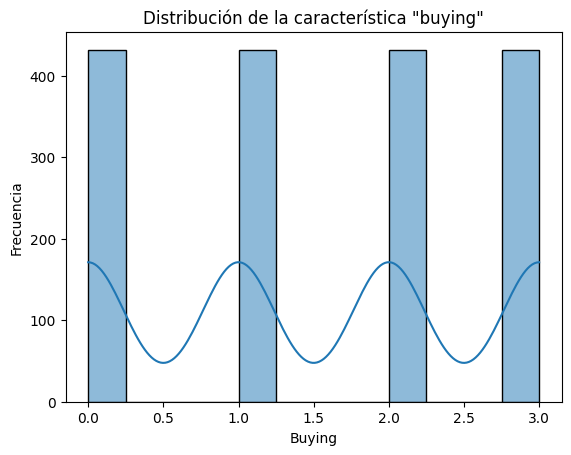

In [15]:
#Histograma
# si buying fuese columna continua
sns.histplot(data['buying'], kde=True)  # kde=True con esto agrego la curva de densidad
plt.title('Distribución de la característica "buying"')
plt.xlabel('Buying')
plt.ylabel('Frecuencia')
plt.show()

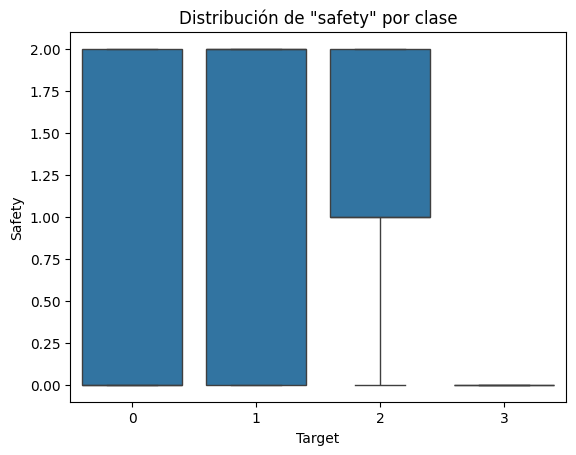

In [16]:
# Boxplot - Diagrama de caja
# si safety fuese una caracteristica continua
sns.boxplot(x='Target', y='safety', data=data)
plt.title('Distribución de "safety" por clase')
plt.xlabel('Target')
plt.ylabel('Safety')
plt.show()

In [17]:
# Divido el dataset en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [18]:
# 1. Modelo: Perceptron
print("\nModelo: Perceptron")
p_model = Perceptron()
p_model.fit(x_train, y_train)


Modelo: Perceptron


Perceptron()

In [19]:
# Predicciones y evaluacion
p_pred = p_model.predict(x_test)
p_confmat = confusion_matrix(y_test, p_pred)
print("Matriz de confusion para Perceptron:")
print(p_confmat)
print("\nReporte de clasificacion para Perceptron:")
print(classification_report(y_test, p_pred))

Matriz de confusion para Perceptron:
[[  5   1 102  10]
 [  0   0  19   0]
 [  7   1 347   3]
 [  1   0  20   3]]

Reporte de clasificacion para Perceptron:
              precision    recall  f1-score   support

           0       0.38      0.04      0.08       118
           1       0.00      0.00      0.00        19
           2       0.71      0.97      0.82       358
           3       0.19      0.12      0.15        24

    accuracy                           0.68       519
   macro avg       0.32      0.28      0.26       519
weighted avg       0.59      0.68      0.59       519



In [20]:
# 2. Modelo: Regresion Logistica
print("\nModelo: Regresion Logistica")
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(x_train, y_train)


Modelo: Regresion Logistica


LogisticRegression(max_iter=200)

In [21]:
# Predicciones y evaluacion
lr_pred = lr_model.predict(x_test)
lr_confmat = confusion_matrix(y_test, lr_pred)
print("Matriz de confusion para Regresion Logistica:")
print(lr_confmat)
print("\nReporte de clasificacion para Regresion Logistica:")
print(classification_report(y_test, lr_pred))

Matriz de confusion para Regresion Logistica:
[[ 21   0  92   5]
 [  3   0  16   0]
 [ 34   0 323   1]
 [ 12   0  11   1]]

Reporte de clasificacion para Regresion Logistica:
              precision    recall  f1-score   support

           0       0.30      0.18      0.22       118
           1       0.00      0.00      0.00        19
           2       0.73      0.90      0.81       358
           3       0.14      0.04      0.06        24

    accuracy                           0.66       519
   macro avg       0.29      0.28      0.27       519
weighted avg       0.58      0.66      0.61       519



c:\Users\Stevens\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Stevens\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Stevens\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [22]:
# 3. Modelo: Random Forest
print("\nModelo: Random Forest")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)


Modelo: Random Forest


RandomForestClassifier(random_state=42)

In [23]:
# Predicciones y evaluacion
rf_pred = rf_model.predict(x_test)
rf_confmat = confusion_matrix(y_test, rf_pred)
print("Matriz de confusión para Random Forest:")
print(rf_confmat)
print("\nReporte de clasificación para Random Forest:")
print(classification_report(y_test, rf_pred))

Matriz de confusión para Random Forest:
[[109   7   1   1]
 [  2  17   0   0]
 [  3   0 355   0]
 [  3   0   0  21]]

Reporte de clasificación para Random Forest:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       118
           1       0.71      0.89      0.79        19
           2       1.00      0.99      0.99       358
           3       0.95      0.88      0.91        24

    accuracy                           0.97       519
   macro avg       0.90      0.92      0.91       519
weighted avg       0.97      0.97      0.97       519



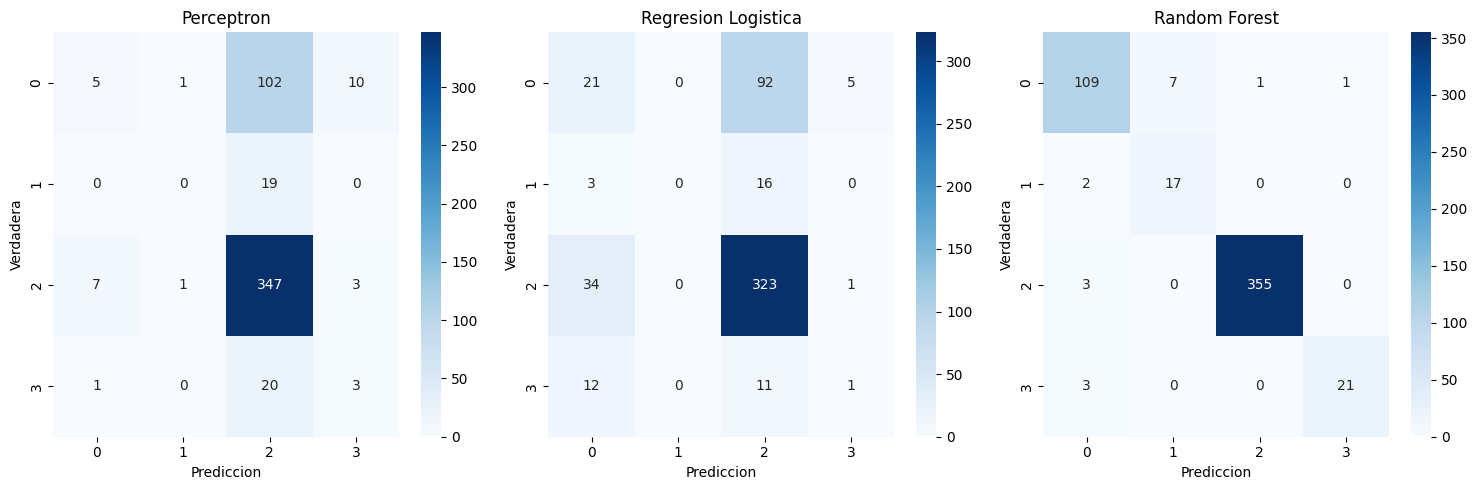

In [24]:
# Visualizacion de las matrices de confusion
modelos = ['Perceptron', 'Regresion Logistica', 'Random Forest']
confmats = [p_confmat, lr_confmat, rf_confmat]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, confmat, title in zip(axes, confmats, modelos):
    sns.heatmap(confmat, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Verdadera')

plt.tight_layout()
plt.show()

In [27]:
# Prueba del modelo (Random Forest)
nuevo_dato = [[3, 3, 0, 0, 1, 1]] 
# modelo entrenado Random Forest para hacer la prediccion
rf_prediccion = rf_model.predict(nuevo_dato)
# Mostrar el resultado de la prediccion
print(f"La clase predicha para el nuevo dato es: {rf_prediccion[0]}")


La clase predicha para el nuevo dato es: 2


## Conclusiones generales

1. 	Random Forest es el mejor modelo en cuanto a la clasificación precisa, ya que tiene la menor cantidad de errores y es más robusto en la mayoría de las clases.
2.  Regresión Logística tiene un buen desempeño, pero comete más errores que Random Forest, especialmente en las clases 0 y 1.
3.	Perceptrón tiene una cantidad considerable de errores, especialmente en las clases 0, 1 y 3, y parece tener un peor rendimiento en comparación con los otros dos modelos.

* Basándonos en estas matrices de confusión podríamos considerar Random Forest como el modelo para esta tarea de clasificación multiclase.

